This notebook covers:
- **EDA** with a large number of visualizations (distributions, correlations, omissions, comparison by target).
- **Data cleaning**, the specifics of anomalies (for example, `DAYS_EMPLOYED == 365243`).
- **Comparison of encoders** of categorical features: `OneHot`, `Ordinary`, `Target`, `CatBoostEncoder'.
- **Feature selection**: `SelectKBest', `Permutation Importance', `SHAP-based` (with aggregation to "raw" features).
- **Interpreted models**: `Logistic Regression`, `Decision Tree`, `LightGBM` (in interpretation-oriented configurations).
- **Interpretation**: importance, coefficients, tree rules, SHAP summary + dependence, PDP.

> **Resource Note:** Calculations can be expensive on a full dataset. Sampling options are provided below to quickly get representative results.


**Abstract (Аннотация).**  
The paper presents a reproducible credit scoring pipeline based on the Home Credit Default Risk dataset: EDA, purification, categorical feature encoding, feature selection, and training of interpreted models (Logistic Regression, Decision Tree, LightGBM) with detailed interpretation (Permutation Importance, SHAP, PDP). We describe the methodology, leak prevention, validation settings, and criteria for selecting final approaches.

**Contents**
1. Introduction and methodology
2. Description of the data and the target variable
3. EDA and key observations
4. Preprocessing and encoding of features
5. Feature selection (SelectKBest, Permutation, SHAP)
6. Models and validation
7. Interpretation of results
8. Conclusions, limitations and further work

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing dependencies


In [2]:
%pip install -q pandas numpy scikit-learn lightgbm xgboost catboost category-encoders shap matplotlib seaborn plotly boruta transformers accelerate sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.8 MB/s eta 0:00:00



## Imports and general settings

In [3]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, accuracy_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Optional libraries
HAS_CE = False
try:
    import category_encoders as ce
    HAS_CE = True
except Exception:
    pass

HAS_LGBM = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    pass

HAS_XGB = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    pass

HAS_CATBOOST = False
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    pass

HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Sampling params for heavy computations
N_SAMPLE_CV = 120_000        # encoder/model comparison
N_SAMPLE_PI_VALID = 15_000   # permutation importance validation
N_SAMPLE_SHAP = 30_000       # SHAP
TOP_K_FEATURES = 50          # number of selected features

# Visualization defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid")


## Data uploading

In [4]:

train_path="/content/drive/MyDrive/application_train.csv"


df = pd.read_csv(train_path)
print('Size application_train:', df.shape)
display(df.head())


Size application_train: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Target variable and class imbalance


TARGET
0    282686
1     24825
Name: count, dtype: int64

Class 1 share: 0.0807


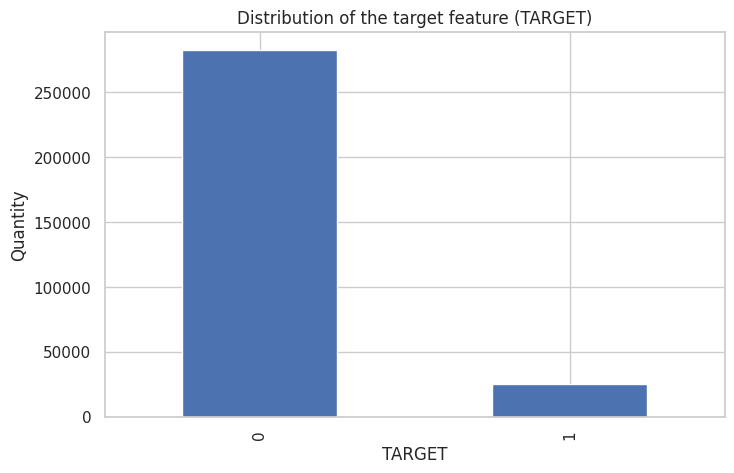

In [5]:

assert 'TARGET' in df.columns, "The TARGET variable is missing from the dataset"
print(df['TARGET'].value_counts())
print('\nClass 1 share:', df['TARGET'].mean().round(4))

# bar chart
ax = df['TARGET'].value_counts().sort_index().plot(kind='bar')
ax.set_title('Distribution of the target feature (TARGET)')
ax.set_xlabel('TARGET')
ax.set_ylabel('Quantity')
plt.show()



**Interpretation (Fig. 1. The distribution Of The `TARGET').**  

There is a pronounced class imbalance (the proportion of `TARGET=1` is significantly lower than `TARGET=0`). This affects the choice of metrics and training.:
- We use **ROC‑AUC** and **PR‑AUC** instead of Accuracy alone.  
- Stratified breakdown of validation is mandatory; for threshold classification, we adjust the threshold based on ** the cost of errors** (false approvals/bounce rate).
- In models, it is acceptable to use `class_weight='balanced` (LR) or `scale_pos_weight` (boosting), if necessary.


## Missing Values
Let’s calculate the share of missing values and look at the top features by number of missing values.


,missing_pct,missing_cnt
COMMONAREA_AVG,0.698723,214865
COMMONAREA_MODE,0.698723,214865
COMMONAREA_MEDI,0.698723,214865
NONLIVINGAPARTMENTS_MEDI,0.694330,213514
NONLIVINGAPARTMENTS_MODE,0.694330,213514
NONLIVINGAPARTMENTS_AVG,0.694330,213514
FONDKAPREMONT_MODE,0.683862,210295
LIVINGAPARTMENTS_AVG,0.683550,210199
LIVINGAPARTMENTS_MEDI,0.683550,210199
LIVINGAPARTMENTS_MODE,0.683550,210199


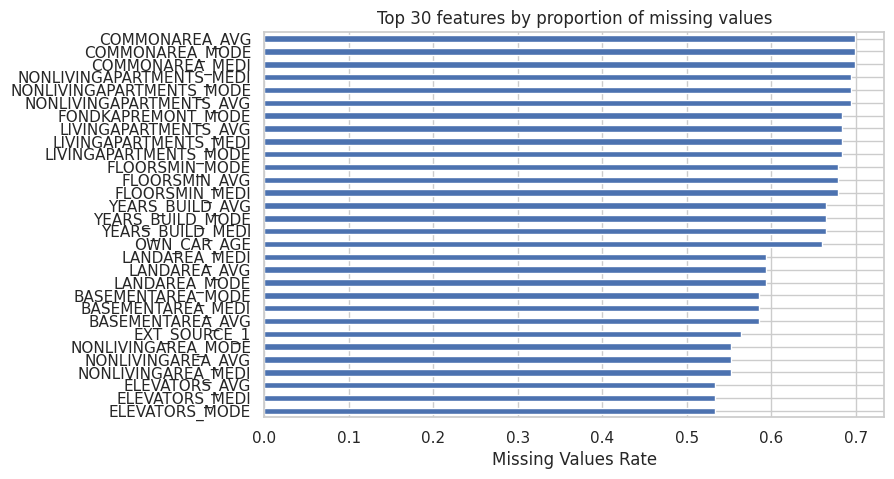

In [6]:
missing = df.isna().mean().sort_values(ascending=False).to_frame('missing_pct')
missing['missing_cnt'] = df.isna().sum().sort_values(ascending=False).values
display(missing.head(20))

top_missing = missing.head(30).iloc[::-1]  # invert it for a horizontal bar chart
ax = top_missing['missing_pct'].plot(kind='barh')
ax.set_xlabel('Missing Values Rate')
ax.set_title('Top 30 features by proportion of missing values')
plt.show()


**Interpretation (Fig. 2. Top-30 in terms of the share of omissions).**  
The upper signs on the chart require a separate imputation strategy. Credit scoring omissions are rarely completely random (MCAR); more often they are MAR/MNAR and informative in themselves. Practically, this means:
- For categorical features, we add a separate category/indicator **`missing`**.  
- For numerical values, we use **median impact** and, if necessary, the "value was skipped" indicator.  
- We process technical markers separately (for example, `DAYS_EMPLOYED == 365243` as `NaN`).  
This scheme reduces bias and preserves information related to the "fact of missing data."


## Basic cleaning and primary feature generation
- In `DAYS_EMPLOYED`, the value `365243` is the technical marker "no data", we will replace it with `NaN`.
- Let's construct the age in years from `DAYS_BIRTH` (if any).
- () A few simple sum/income relations.

**Explanation of the preprocessing.**  
- Replace `DAYS_EMPLOYED == 365243` with `NaN', since this is the "no seniority" code in the original upload.  
- Derived features `AGE_YEARS`, `CREDIT_INCOME_PCT', `ANNUITY_INCOME_PCT`, `CREDIT_ANNUITY_RATIO' introduce economic meaning and improve the expressivity of the model.  
- All calculations are performed **inside the pipeline** on training folds to eliminate leakage.


In [7]:

df_clean = df.copy()

# Specifics of Home Credit: anomaly 365243 in DAYS_EMPLOYED
if 'DAYS_EMPLOYED' in df_clean.columns:
    df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)

# Age
if 'DAYS_BIRTH' in df_clean.columns:
    df_clean['AGE_YEARS'] = - df_clean['DAYS_BIRTH'] / 365.25

# Simple relationships (if there are columns)
def safe_ratio(a, b):
    return a / (b.replace(0, np.nan)) if hasattr(b, 'replace') else a / b

if set(['AMT_CREDIT','AMT_INCOME_TOTAL']).issubset(df_clean.columns):
    df_clean['CREDIT_INCOME_PCT'] = df_clean['AMT_CREDIT'] / (df_clean['AMT_INCOME_TOTAL'].replace(0, np.nan))
if set(['AMT_ANNUITY','AMT_INCOME_TOTAL']).issubset(df_clean.columns):
    df_clean['ANNUITY_INCOME_PCT'] = df_clean['AMT_ANNUITY'] / (df_clean['AMT_INCOME_TOTAL'].replace(0, np.nan))
if set(['AMT_CREDIT','AMT_ANNUITY']).issubset(df_clean.columns):
    df_clean['CREDIT_ANNUITY_RATIO'] = df_clean['AMT_CREDIT'] / (df_clean['AMT_ANNUITY'].replace(0, np.nan))

print('Size after basic cleaning/FE:', df_clean.shape)


Size after basic cleaning/FE: (307511, 126)



## Automatic feature type detection
Integers with low cardinality are treated as categorical features.


In [8]:

def detect_feature_types(df_in: pd.DataFrame, target: str, int_as_cat_max_uniques: int = 20):
    numeric, categorical = [], []
    for col in df_in.columns:
        if col == target:
            continue
        s = df_in[col]
        if pd.api.types.is_numeric_dtype(s):
            if pd.api.types.is_integer_dtype(s) and s.nunique(dropna=True) <= int_as_cat_max_uniques:
                categorical.append(col)
            else:
                numeric.append(col)
        else:
            categorical.append(col)
    return numeric, categorical

numeric_cols, categorical_cols = detect_feature_types(df_clean, 'TARGET', int_as_cat_max_uniques=20)
print('Numerical:', len(numeric_cols), '| Categorical:', len(categorical_cols))


Numerical: 74 | Categorical: 51



## Numerical signs: correlation with `TARGET' (Spearman)
Let's show the top 20 by absolute correlation.


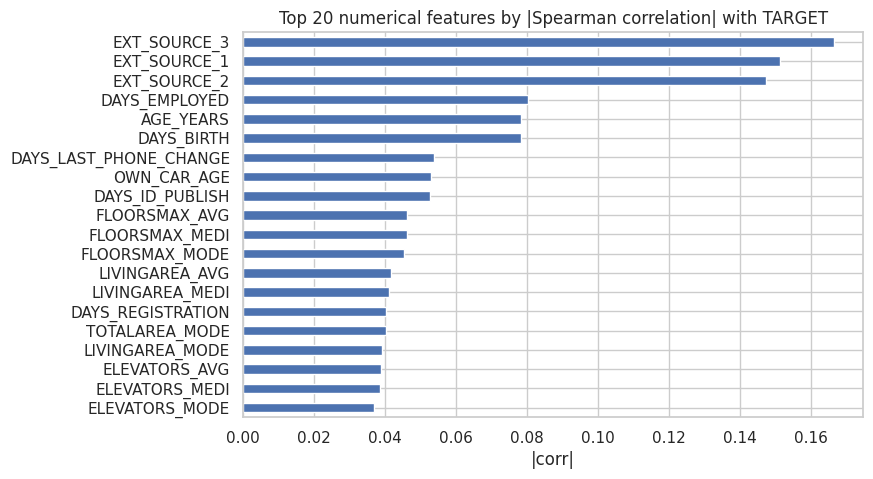

In [9]:

num_for_corr = [c for c in numeric_cols if c != 'TARGET']
corr_s = df_clean[num_for_corr + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
top20 = corr_s.head(20).iloc[::-1]

ax = top20.plot(kind='barh')
ax.set_title('Top 20 numerical features by |Spearman correlation| with TARGET')
ax.set_xlabel('|corr|')
plt.show()



**Interpretation (Fig. 3. Top-20 |Spearman corr|).**  
Spearman's correlation indicates monotonous connections between signs and risk. In credit scoring tasks, strong anti‑correlators are expected — external scoring sources `EXT_SOURCE_*` and age (`DAYS_BIRTH`), and load factors (loan amount, annuity, credit/income ratio) show a positive relationship with risk. It should be remembered that correlation ** is not** equal to causality, and multicollinearity can "blur" the contribution of individual features.


## Categorical features: target share by category
For features with cardinality < 10, we visualize the average `TARGET` by category.


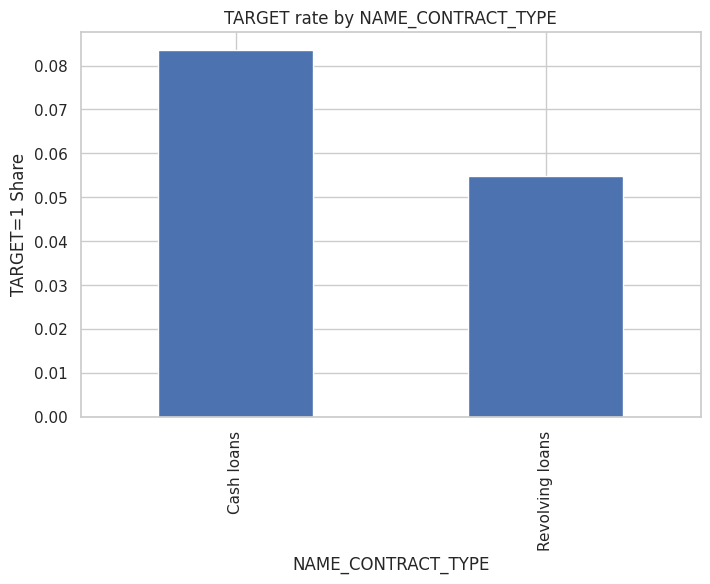

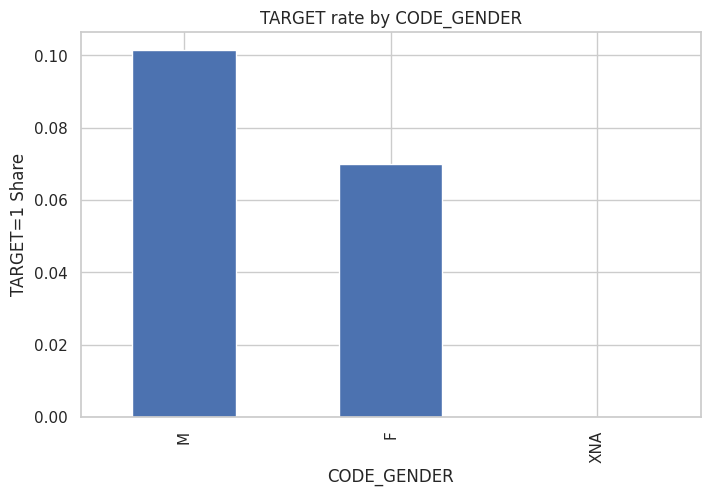

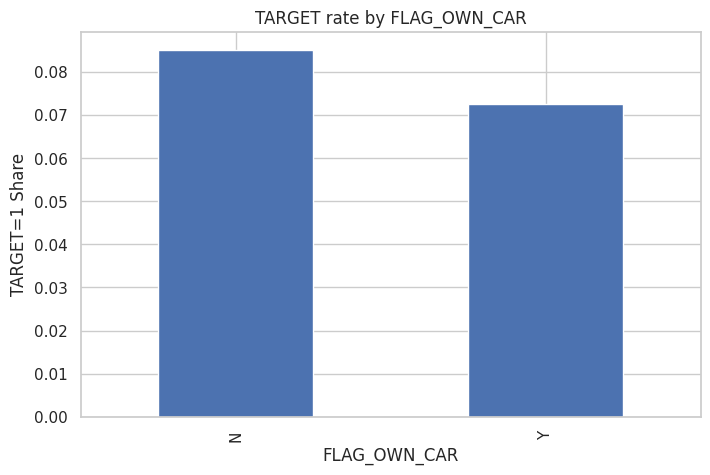

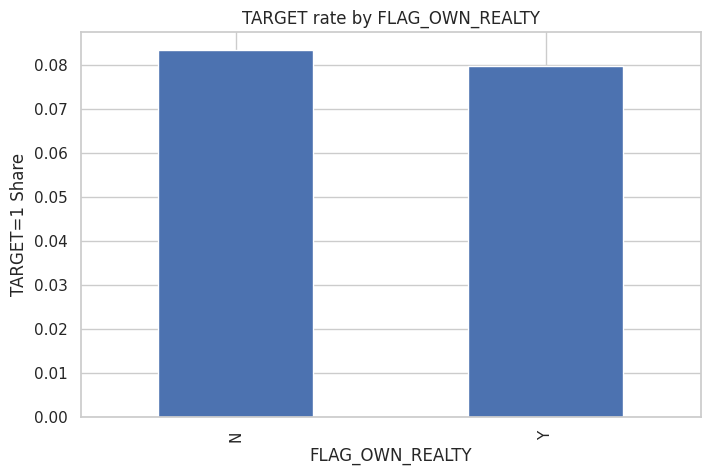

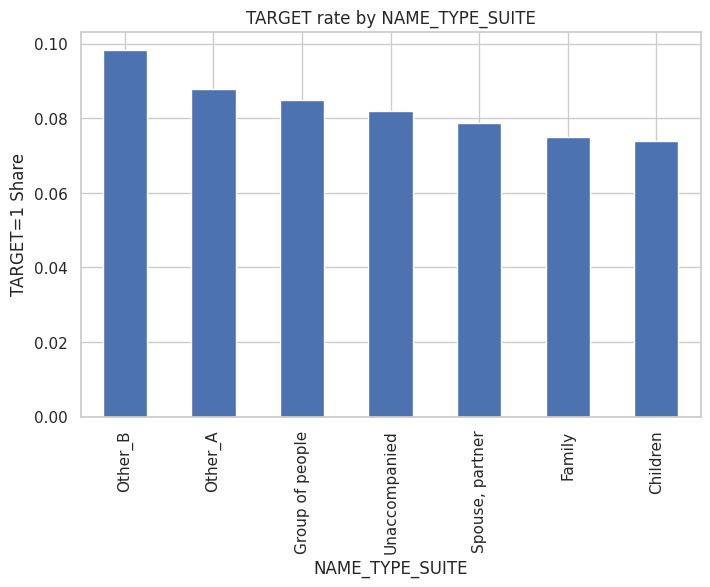

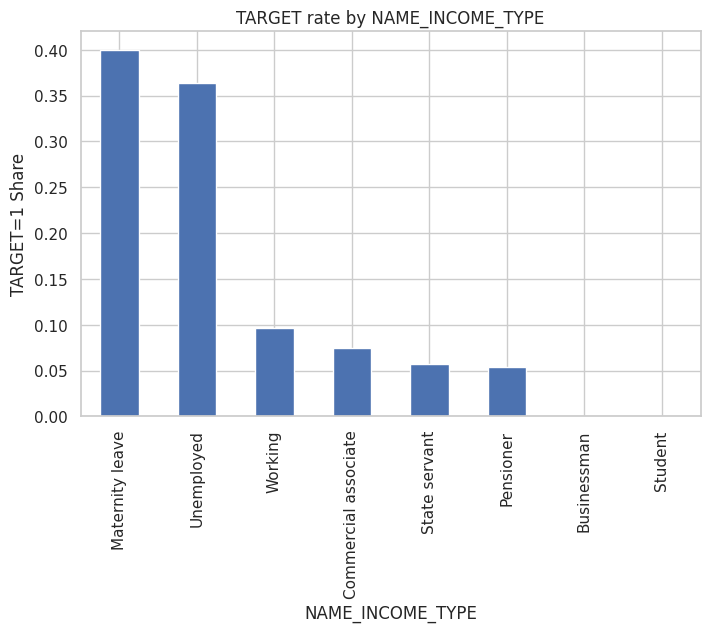

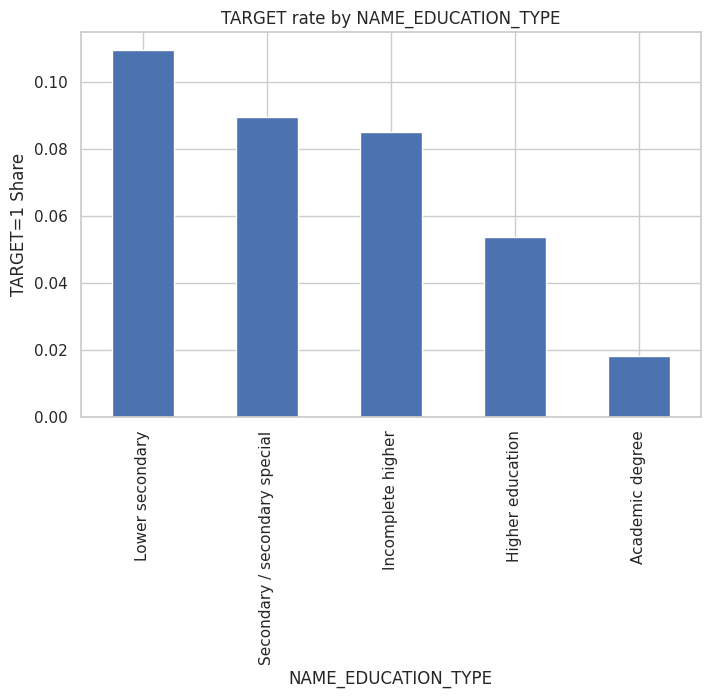

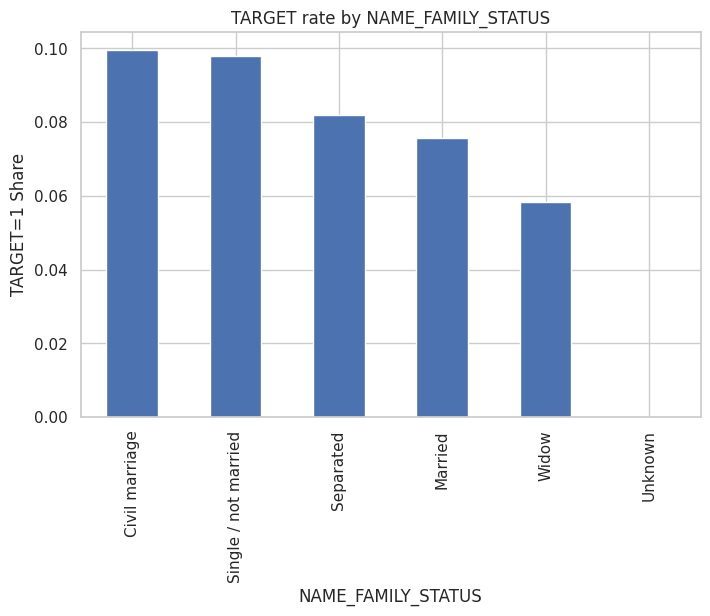

In [10]:

low_card = [c for c in categorical_cols if df_clean[c].nunique(dropna=False) <= 10]
for c in low_card[:8]:
    rates = df_clean.groupby(c)['TARGET'].mean().sort_values(ascending=False)
    ax = rates.plot(kind='bar')
    ax.set_ylabel('TARGET=1 Share')
    ax.set_title(f'TARGET rate by {c}')
    plt.show()


**Interpretation (Fig. 4. TARGET‑rate for categorical features).**  
The bar charts show the default percentage by category. The observations are typical: less stable socio‑economic statuses (temporary employment, lack of property) correlate with increased risk; more stable statuses correlate with reduced risk. For high‑margin features, it makes sense to switch to target coding in order to avoid an explosion of dimensionality.


## Heat map of correlations (top 25 numerical features according to |corr|)

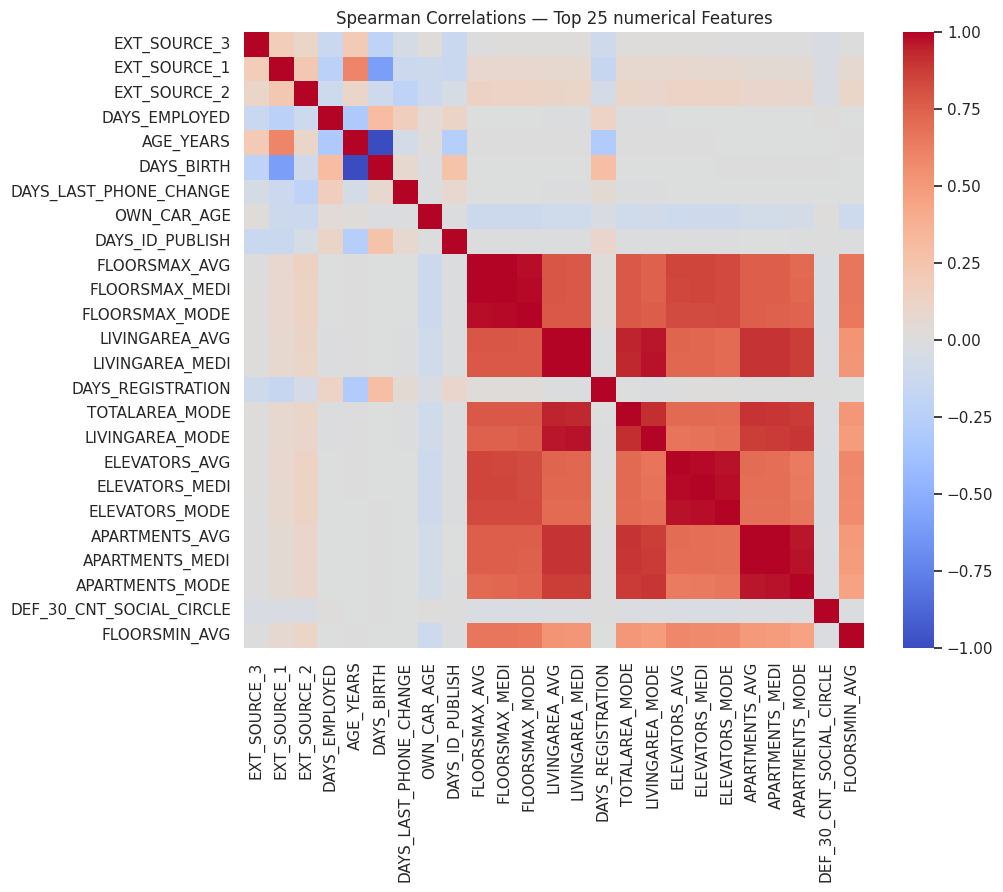

In [11]:

top25_cols = corr_s.head(25).index.tolist()
corr_mat = df_clean[top25_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, cmap='coolwarm', center=0)
plt.title('Spearman Correlations — Top 25 numerical Features')
plt.show()


**Interpretation (Fig. 5. Spearman's heat map).**  
Groups of closely related features (clusters) signal multicollinearity. This is important when choosing models: linear models can "suffer" from unstable coefficients, whereas trees and boosting are more stable. For a linear model, more rigorous feature selection or regularization is appropriate.



## Preprocessor construction and auxiliary functions

In [12]:

from typing import List, Dict, Tuple
from sklearn.base import BaseEstimator

def make_preprocessor(encoder_name: str,
                      numeric_features: List[str],
                      categorical_features: List[str],
                      scale_numeric: bool) -> ColumnTransformer:
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    if encoder_name.lower() == 'onehot':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
    elif encoder_name.lower() == 'ordinal':
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])
    elif encoder_name.lower() in ('target', 'catboost'):
        if not HAS_CE:
            raise RuntimeError("Требуется пакет category-encoders. Установите и перезапустите.")
        enc = ce.TargetEncoder() if encoder_name.lower() == 'target' else ce.CatBoostEncoder()
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('tgt', enc)
        ])
    else:
        raise ValueError(f'Неизвестный encoder: {encoder_name}')

    pre = ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_features),
            ('cat', cat_pipe, categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )
    return pre

def get_feature_names_after_preprocess(fitted_pre: ColumnTransformer) -> np.ndarray:
    names = []
    for name, trans, cols in fitted_pre.transformers_:
        if name == 'num':
            names.extend(list(cols))
        elif name == 'cat':
            cat_cols = list(cols)
            last_step_name, last_step = trans.steps[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                try:
                    out = last_step.get_feature_names_out(cat_cols)
                    names.extend(list(out))
                except Exception:
                    names.extend([f'{c}__enc' for c in cat_cols])
            else:
                suffix = '__ord' if last_step_name == 'ord' else '__enc'
                names.extend([f'{c}{suffix}' for c in cat_cols])
    return np.array(names)

def map_transformed_to_raw(fitted_pre: ColumnTransformer) -> Dict[str, str]:
    mapping = {}
    for name, trans, cols in fitted_pre.transformers_:
        if name == 'num':
            for c in cols:
                mapping[c] = c
        elif name == 'cat':
            cat_cols = list(cols)
            last_step_name, last_step = trans.steps[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                out = last_step.get_feature_names_out(cat_cols)
                for tname in out:
                    raw = str(tname).split('_', 1)[0]
                    mapping[str(tname)] = raw
            else:
                suffix = '__ord' if last_step_name == 'ord' else '__enc'
                for c in cat_cols:
                    mapping[f'{c}{suffix}'] = c
    return mapping


## Encoder comparison (OneHot / Ordinal / Target / CatBoostEncoder) x models (LogReg / MLP small / MLP deep / LightGBM)
We evaluate ROC AUC, AP, LogLoss, and Accuracy using cross-validation on a sample.

Two lightweight neural models are added:
- `MLP small` (one hidden layer) as a baseline nonlinear model;
- `MLP deep` (two hidden layers) to test whether extra depth gives measurable gains.


,encoder,model,roc_auc,ap,logloss,accuracy
0,target,lgbm,0.759461,0.239964,0.245428,0.919983
1,ordinal,lgbm,0.758915,0.240913,0.245470,0.919842
2,onehot,lgbm,0.758883,0.240384,0.245547,0.919933
3,catboost,lgbm,0.758645,0.240396,0.245609,0.919883
4,onehot,logreg,0.744245,0.218215,0.249999,0.919408
5,ordinal,logreg,0.743412,0.216473,0.250207,0.919367
6,target,logreg,0.740436,0.213963,0.251086,0.919667
7,catboost,logreg,0.739854,0.213201,0.251282,0.919558
8,onehot,mlp_deep,0.725291,0.196855,0.256812,0.920125
9,ordinal,mlp_deep,0.690461,0.168503,0.264003,0.920175


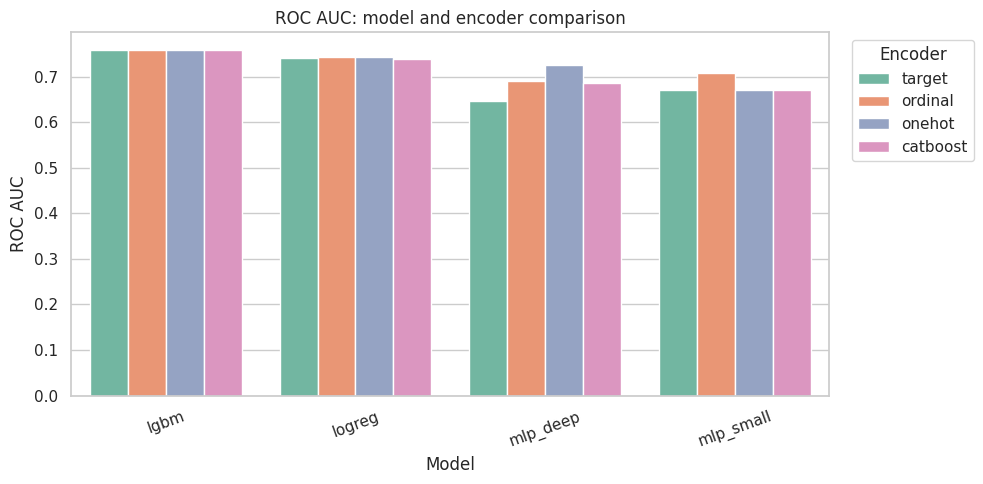

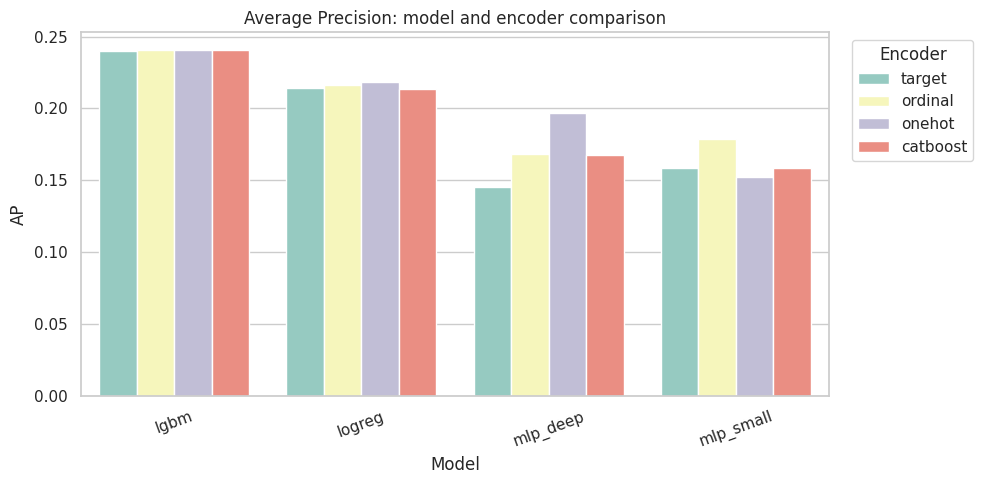

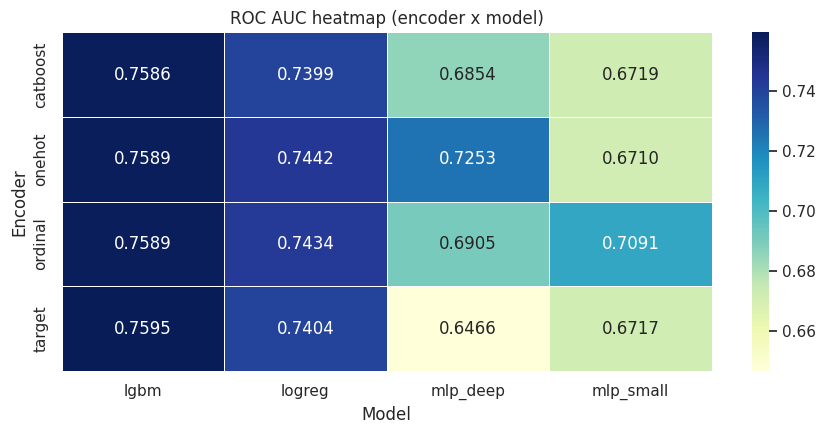

In [13]:
from dataclasses import dataclass

@dataclass
class EvalResult:
    encoder: str
    model: str
    roc_auc: float
    ap: float
    logloss: float
    accuracy: float


def build_model(model_name: str):
    m = model_name.lower()
    if m == 'logreg':
        return LogisticRegression(max_iter=1200)
    if m == 'lgbm':
        assert HAS_LGBM, "LightGBM is not installed"
        return LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    if m == 'mlp_small':
        return MLPClassifier(
            hidden_layer_sizes=(64,), activation='relu', solver='adam',
            alpha=1e-4, learning_rate_init=1e-3, batch_size=512,
            max_iter=120, early_stopping=True, n_iter_no_change=10,
            random_state=RANDOM_STATE
        )
    if m == 'mlp_deep':
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
            alpha=3e-4, learning_rate_init=8e-4, batch_size=512,
            max_iter=160, early_stopping=True, n_iter_no_change=12,
            random_state=RANDOM_STATE
        )
    raise ValueError(f'Unknown model: {model_name}')


def evaluate_encoder_with_model(X: pd.DataFrame, y: pd.Series,
                                encoder_name: str, model_name: str,
                                numeric_features: List[str], categorical_features: List[str],
                                cv_splits: int = 5) -> EvalResult:
    scale_numeric = model_name.lower() in ('logreg', 'mlp_small', 'mlp_deep')
    pre = make_preprocessor(encoder_name, numeric_features, categorical_features, scale_numeric)
    model = build_model(model_name)
    pipe = Pipeline([('pre', pre), ('model', model)])

    scoring = {
        'roc_auc': 'roc_auc',
        'ap': 'average_precision',
        'logloss': 'neg_log_loss',
        'accuracy': 'accuracy'
    }
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

    # MLP runs with n_jobs=1 to avoid memory spikes on dense OHE matrices.
    n_jobs_cv = 1 if model_name.lower().startswith('mlp') else -1
    res = cross_validate(pipe, X, y, scoring=scoring, cv=cv, n_jobs=n_jobs_cv, error_score='raise')

    return EvalResult(
        encoder=encoder_name,
        model=model_name,
        roc_auc=float(np.mean(res['test_roc_auc'])),
        ap=float(np.mean(res['test_ap'])),
        logloss=float(-np.mean(res['test_logloss'])),
        accuracy=float(np.mean(res['test_accuracy']))
    )


# CV samples
# Use a smaller subset for neural nets to keep runtime practical.
df_cv = df_clean.sample(min(N_SAMPLE_CV, len(df_clean)), random_state=RANDOM_STATE)
df_cv_nn = df_cv.sample(min(40_000, len(df_cv)), random_state=RANDOM_STATE)

X_cv = df_cv.drop(columns=['TARGET'])
y_cv = df_cv['TARGET']
X_cv_nn = df_cv_nn.drop(columns=['TARGET'])
y_cv_nn = df_cv_nn['TARGET']

encoders = ['onehot', 'ordinal']
if HAS_CE:
    encoders += ['target', 'catboost']

models = ['logreg', 'mlp_small', 'mlp_deep'] + (['lgbm'] if HAS_LGBM else [])

results = []
for m in models:
    X_eval, y_eval = (X_cv_nn, y_cv_nn) if m.startswith('mlp') else (X_cv, y_cv)
    cv_splits = 3 if m.startswith('mlp') else 5

    for e in encoders:
        try:
            r = evaluate_encoder_with_model(
                X_eval, y_eval, e, m, numeric_cols, categorical_cols, cv_splits=cv_splits
            )
            results.append(r.__dict__)
        except Exception as ex:
            print(f'[WARN] {m} + {e}: {ex}')
            results.append({
                'encoder': e, 'model': m,
                'roc_auc': np.nan, 'ap': np.nan, 'logloss': np.nan, 'accuracy': np.nan
            })

res_df = pd.DataFrame(results).sort_values(['model', 'roc_auc'], ascending=[True, False]).reset_index(drop=True)
display(res_df)

# Plot 1: ROC AUC
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=res_df, x='model', y='roc_auc', hue='encoder', palette='Set2')
ax.set_title('ROC AUC: model and encoder comparison')
ax.set_xlabel('Model')
ax.set_ylabel('ROC AUC')
plt.xticks(rotation=20)
plt.legend(title='Encoder', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: AP
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=res_df, x='model', y='ap', hue='encoder', palette='Set3')
ax.set_title('Average Precision: model and encoder comparison')
ax.set_xlabel('Model')
ax.set_ylabel('AP')
plt.xticks(rotation=20)
plt.legend(title='Encoder', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 3: heatmap by ROC AUC
pivot_auc = res_df.pivot(index='encoder', columns='model', values='roc_auc')
plt.figure(figsize=(9, 4.5))
sns.heatmap(pivot_auc, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=.5)
plt.title('ROC AUC heatmap (encoder x model)')
plt.xlabel('Model')
plt.ylabel('Encoder')
plt.tight_layout()
plt.show()


**Interpretation (Fig. 6-8).**
Two neural models were added as lightweight nonlinear benchmarks:
- **MLP small** checks whether basic nonlinear interactions improve quality;
- **MLP deep** checks whether extra depth gives additional gain.

Why these models:
- easy to implement in `sklearn`;
- can be run in the same `Pipeline` as classical methods;
- fair side-by-side comparison with LR/trees/LightGBM on identical metrics.

Practical value:
- if MLP improves `ROC-AUC/AP`, nonlinear signal is present;
- if the gain is small, interpretable models remain preferable for production.


## SelectKBest (mutual_info) + model (default is LightGBM)



In [14]:

def select_kbest_pipeline(X: pd.DataFrame, y: pd.Series,
                          encoder_name: str, numeric_features: List[str],
                          categorical_features: List[str], k: int,
                          model_name: str = 'lgbm') -> tuple:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    scale_numeric = (model_name.lower() == 'logreg')
    pre = make_preprocessor(encoder_name, numeric_features, categorical_features, scale_numeric)
    selector = SelectKBest(mutual_info_classif, k=k)

    if model_name.lower() == 'logreg':
        model = LogisticRegression(max_iter=1000)
    else:
        assert HAS_LGBM, "LightGBM не установлен"
        model = LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    pipe = Pipeline([('pre', pre), ('kbest', selector), ('model', model)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:,1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        'roc_auc': roc_auc_score(y_test, proba),
        'ap': average_precision_score(y_test, proba),
        'logloss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred)
    }
    return pipe, metrics

pipe_kbest, kbest_metrics = select_kbest_pipeline(
    X_cv.drop(columns=[]), y_cv,
    encoder_name='onehot', numeric_features=numeric_cols, categorical_features=categorical_cols,
    k=min(TOP_K_FEATURES, len(numeric_cols) + len(categorical_cols)), model_name='lgbm' if HAS_LGBM else 'logreg'
)
print('SelectKBest metrics:', kbest_metrics)


[LightGBM] [Info] Number of positive: 7716, number of negative: 88284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 793
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080375 -> initscore=-2.437263
[LightGBM] [Info] Start training from score -2.437263
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

**Interpretation.**  
'SelectKBest' (mutual information) acts as a fast filter: it selects features with the most mutual information with the target. It does not take into account the interaction between the signs, so it is convenient to use it as **primary screening**, and then confirm the significance with permutations or shaps.


## Permutation Importance (at the level of "raw" attributes)
Let's build a pipeline `Preprocessor(OneHot) → LightGBM` and evaluate the importance of permutations on validation.


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.232378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12771
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 270
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,feature,importance_mean,importance_std
0,EXT_SOURCE_3,0.055584,0.003205
1,EXT_SOURCE_2,0.040863,0.003054
2,CREDIT_ANNUITY_RATIO,0.020358,0.001280
3,EXT_SOURCE_1,0.016108,0.001865
4,AMT_GOODS_PRICE,0.015318,0.002051
5,AMT_CREDIT,0.005280,0.001340
6,AMT_ANNUITY,0.003851,0.001355
7,CODE_GENDER,0.003476,0.001458
8,NAME_EDUCATION_TYPE,0.003163,0.000985
9,NAME_CONTRACT_TYPE,0.002613,0.001536


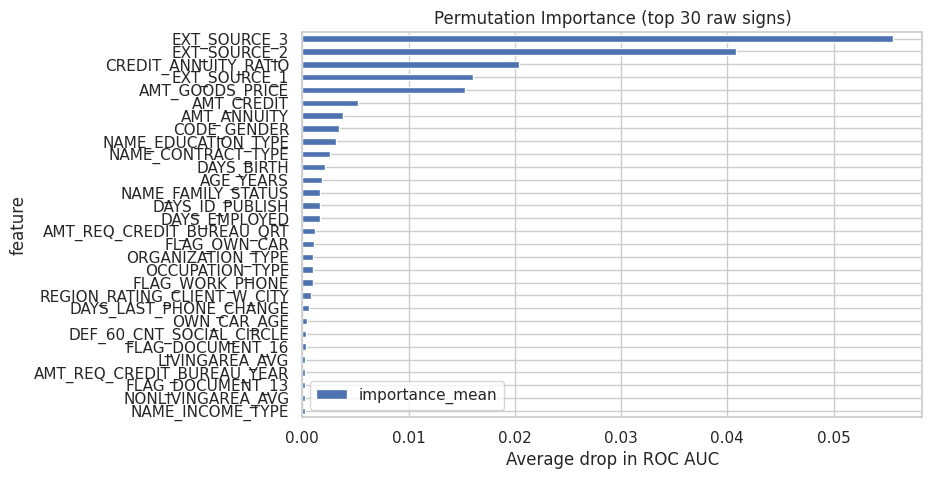

In [15]:

def build_pipe_for_raw_features(encoder_name: str, raw_numeric: List[str], raw_categorical: List[str], model_name: str):
    scale_numeric = (model_name.lower() == 'logreg')
    pre = make_preprocessor(encoder_name, raw_numeric, raw_categorical, scale_numeric)
    if model_name.lower() == 'logreg':
        model = LogisticRegression(max_iter=1000)
    else:
        assert HAS_LGBM, "LightGBM is not installed"
        model = LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        )
    return Pipeline([('pre', pre), ('model', model)])

# Holdout for PI
X_train_pi, X_valid_pi, y_train_pi, y_valid_pi = train_test_split(
    df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
    test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
)
# To speed up, reduce the validation
val_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_valid_pi), size=min(N_SAMPLE_PI_VALID, len(X_valid_pi)), replace=False)
X_valid_pi_s = X_valid_pi.iloc[val_idx]
y_valid_pi_s = y_valid_pi.iloc[val_idx]

pipe_pi = build_pipe_for_raw_features('onehot', numeric_cols, categorical_cols, model_name='lgbm' if HAS_LGBM else 'logreg')
pipe_pi.fit(X_train_pi, y_train_pi)

r = permutation_importance(pipe_pi, X_valid_pi_s, y_valid_pi_s, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
pi_df = pd.DataFrame({
    'feature': X_valid_pi_s.columns,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
display(pi_df.head(30))

top_raw_perm = pi_df.head(TOP_K_FEATURES)['feature'].tolist()

ax = pi_df.head(30).iloc[::-1].plot(kind='barh', x='feature', y='importance_mean')
ax.set_title('Permutation Importance (top 30 raw signs)')
ax.set_xlabel('Average drop in ROC AUC')
plt.show()



**Interpretation (Fig. 7. Permutation importance according to "raw" features).**  
Permutations measure the drop of a metric when a column is randomly rearranged. The advantage is that they relate to the **source** features before encoding, which simplifies business interpretation. `EXT_SOURCE_*`, `DAYS_BIRTH`, debt load indexes and derivative relationships are consistently appearing among the top features.



## SHAP‑based selection and interpretation ()
We will use `LightGBM` + `TreeExplainer'. For big data, we sample validation.


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.333668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12771
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 270
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,raw,abs_shap
42,EXT_SOURCE_3,0.352066
41,EXT_SOURCE_2,0.321570
63,NAME,0.263264
3,AMT_GOODS_PRICE,0.183763
43,FLAG,0.182867
24,CREDIT_ANNUITY_RATIO,0.176984
40,EXT_SOURCE_1,0.162519
20,CODE,0.115200
27,DAYS_EMPLOYED,0.105396
1,AMT_ANNUITY,0.096182


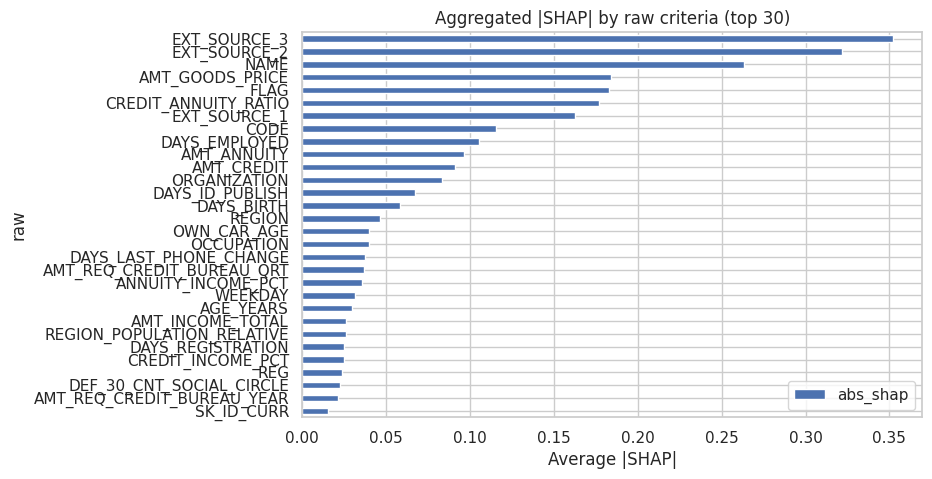

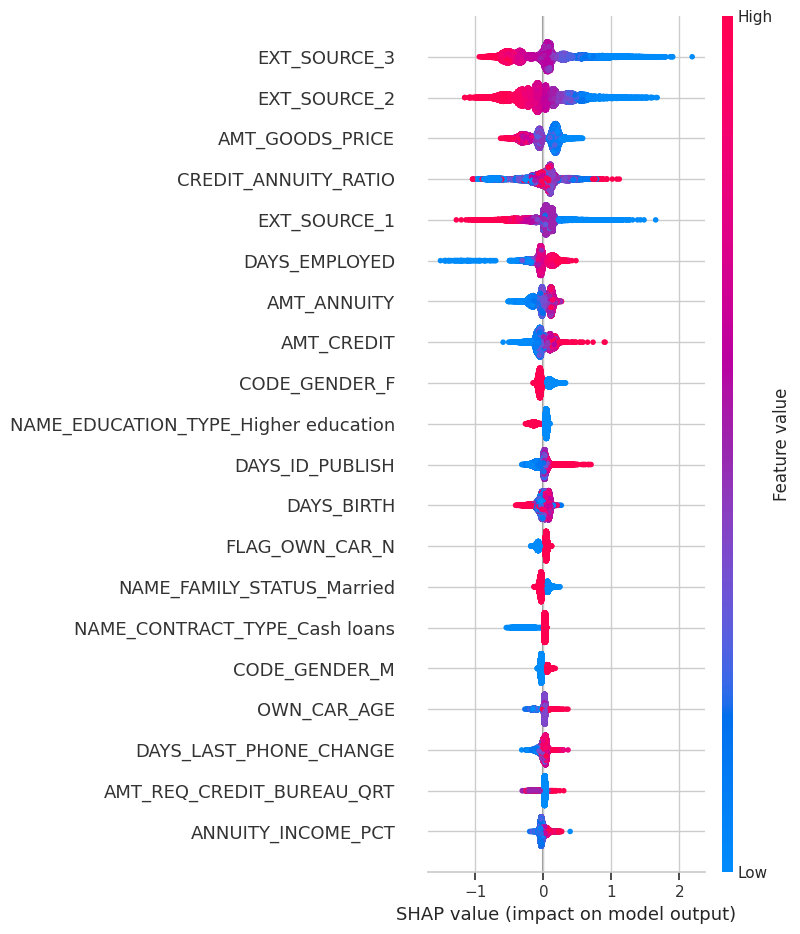

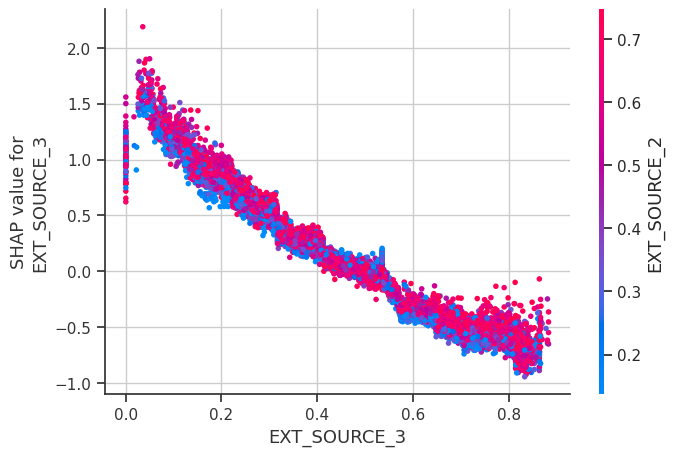

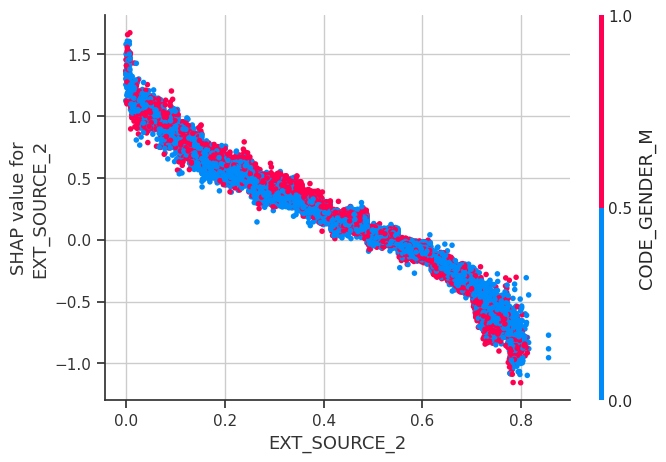

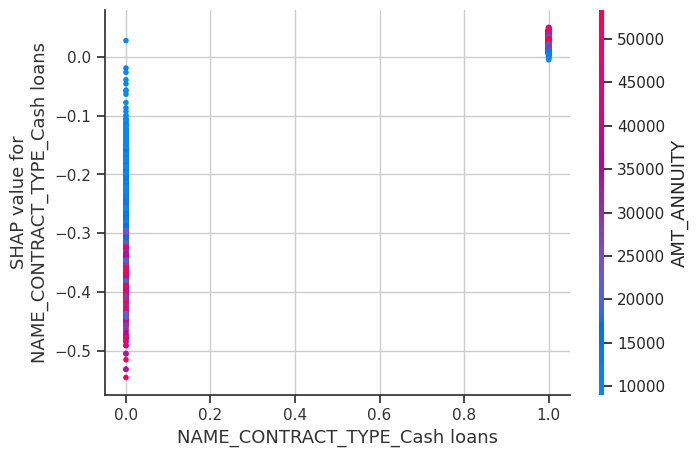

In [16]:

top_raw_shap = []
if HAS_SHAP and HAS_LGBM:
    # Train pipeline on train subset
    X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(
        df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
        test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
    )
    # let's limit valid for shap
    valid_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_valid_s), size=min(N_SAMPLE_SHAP, len(X_valid_s)), replace=False)
    Xv = X_valid_s.iloc[valid_idx]
    yv = y_valid_s.iloc[valid_idx]

    pre = make_preprocessor('onehot', numeric_cols, categorical_cols, scale_numeric=False)
    model = LGBMClassifier(
        n_estimators=700, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, importance_type='gain'
    )
    pipe_shap = Pipeline([('pre', pre), ('model', model)])
    pipe_shap.fit(X_train_s, y_train_s)

    Xv_trans = pipe_shap.named_steps['pre'].transform(Xv)
    model_f = pipe_shap.named_steps['model']
    explainer = shap.TreeExplainer(model_f, feature_perturbation="tree_path_dependent")
    sv = explainer.shap_values(Xv_trans)
    if isinstance(sv, list):
        sv = sv[1]  # for a binary task

    feat_names_trans = get_feature_names_after_preprocess(pipe_shap.named_steps['pre'])
    to_raw = map_transformed_to_raw(pipe_shap.named_steps['pre'])
    df_imp = pd.DataFrame({
        'transformed': feat_names_trans,
        'raw': [to_raw.get(n, n) for n in feat_names_trans],
        'abs_shap': np.abs(sv).mean(axis=0)
    })
    agg = df_imp.groupby('raw', as_index=False)['abs_shap'].sum().sort_values('abs_shap', ascending=False)
    display(agg.head(30))

    top_raw_shap = agg.head(TOP_K_FEATURES)['raw'].tolist()

    # Aggregated bar chart |SHAP|
    ax = agg.head(30).iloc[::-1].plot(kind='barh', x='raw', y='abs_shap')
    ax.set_title('Aggregated |SHAP| by raw criteria (top 30)')
    ax.set_xlabel('Average |SHAP|')
    plt.show()

    # SHAP summary (for transformed features)
    shap.summary_plot(sv, Xv_trans, feature_names=feat_names_trans, show=True)

    # SHAP dependence for several top features (by raw names → choose one transformed one)
    for raw_name in top_raw_shap[:3]:
        candidates = [t for t in feat_names_trans if to_raw.get(t, None) == raw_name]
        if not candidates:
            continue
        shap.dependence_plot(candidates[0], sv, Xv_trans, feature_names=feat_names_trans, show=True)
else:
    print("SHAP or LightGBM are not available. Skipping the SHAP block.")


**Interpretation (Fig. 8. Aggregated |SHAP|; Fig. 9. SHAP summary; Fig. 10. SHAP dependence).**  
SHAP values show the contribution of features to the prediction for each observation and provide both **global** (distribution of importance) and **local** (for a specific client) interpretation.  
- On the summary chart, the importance is shown from left to right, the color reflects the value of the feature; the slope of the cloud shows the direction of influence.  
- Dependency graphs allow you to see **non-linearities** and **interactions** between features.  
Aggregation by "raw" attributes in OHE makes conclusions comparable to business logic.

## Holdout training: interpretable and neural models
Using selected features (Permutation Importance or SHAP), we train:
- `LogisticRegression`
- `DecisionTree` (shallow tree)
- `MLP small` (1 hidden layer)
- `MLP deep` (2 hidden layers)
- `LightGBM` (interpretable shallow configuration)


Selected features -> numeric: 30 | categorical: 20
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094945 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6222
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 165
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

,model,roc_auc,ap,logloss,accuracy
0,LightGBM,0.771070,0.263034,0.241984,0.919906
1,MLP deep,0.751445,0.235423,0.248343,0.919565
2,MLP small,0.750474,0.234406,0.249031,0.919370
3,LogReg,0.748021,0.230071,0.249116,0.919500
4,DecisionTree,0.701817,0.175687,0.259519,0.919272


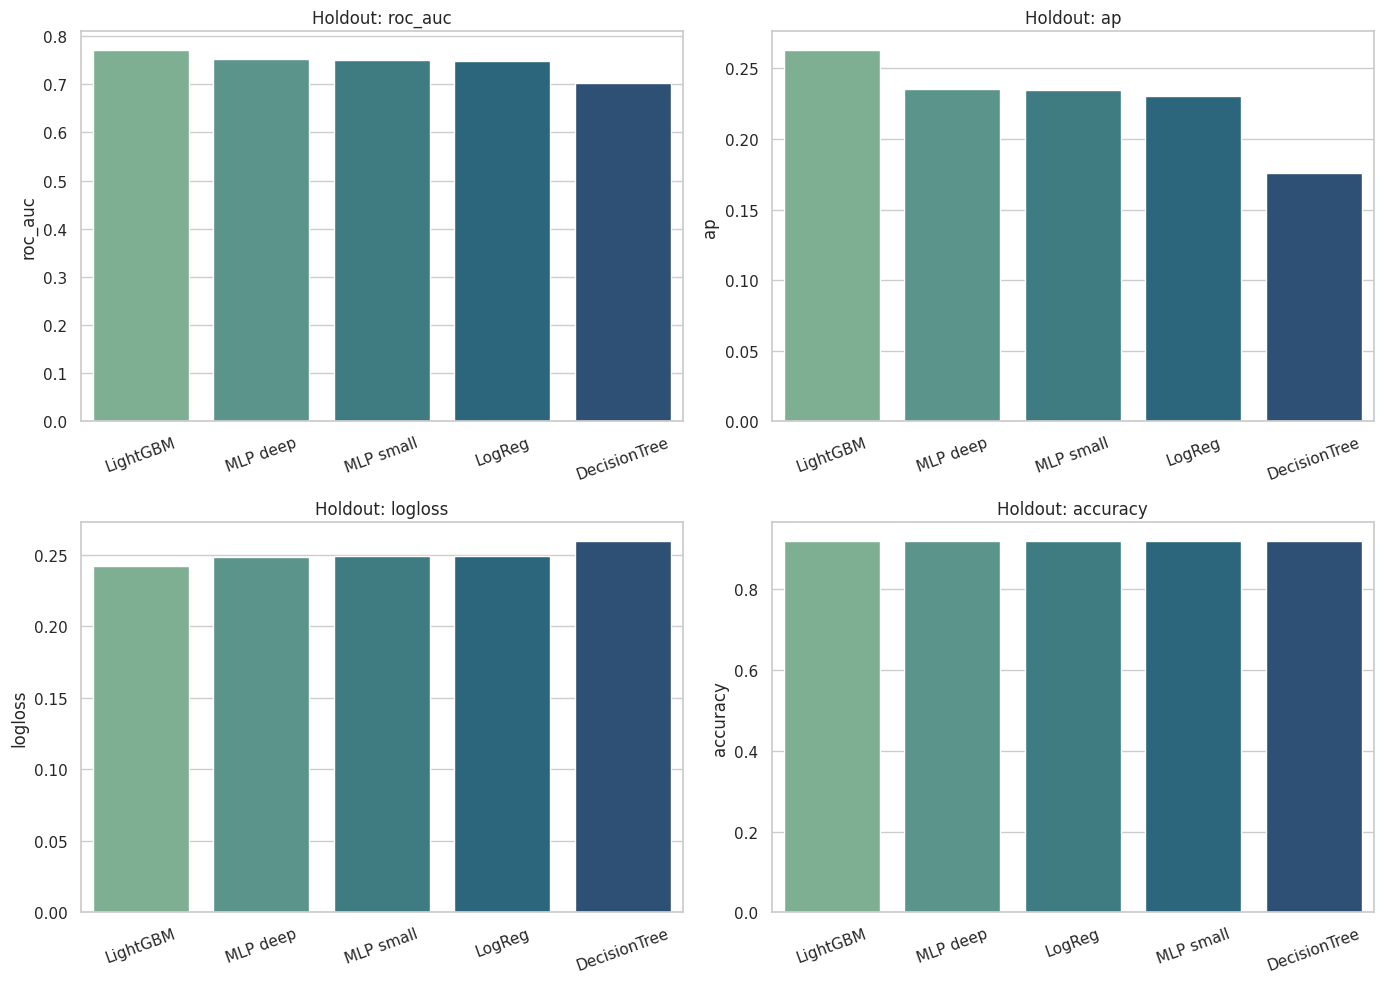

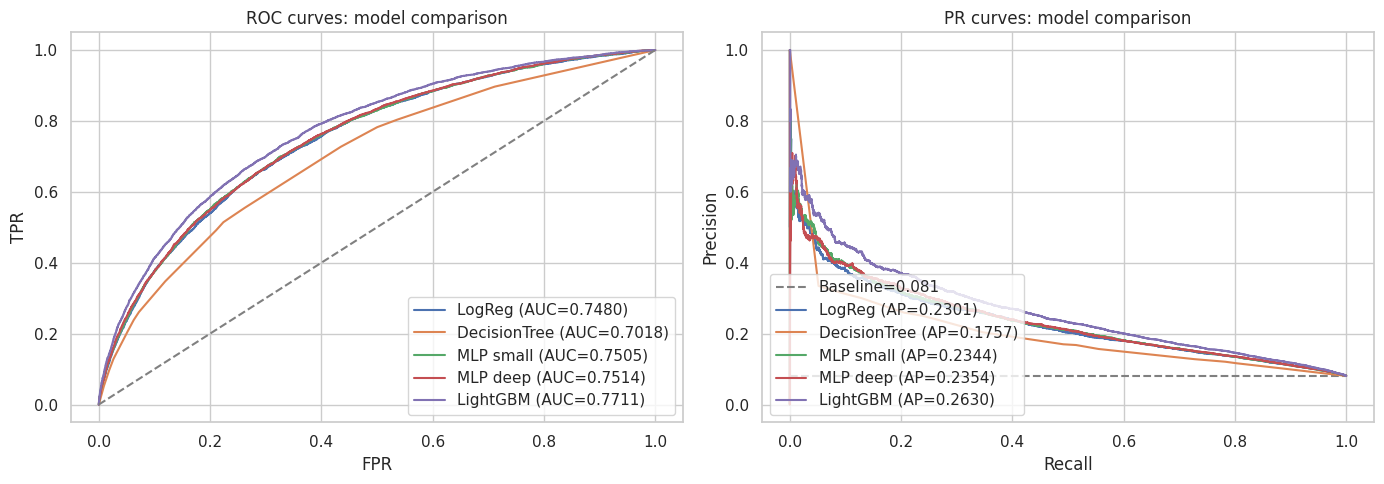

In [17]:
def evaluate_on_holdout(pipe: Pipeline, X_train: pd.DataFrame, y_train: pd.Series,
                        X_test: pd.DataFrame, y_test: pd.Series):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'roc_auc': roc_auc_score(y_test, proba),
        'ap': average_precision_score(y_test, proba),
        'logloss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred)
    }, proba


def plot_roc_pr_multi(y_true, proba_dict: Dict[str, np.ndarray]):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC
    for name, proba in proba_dict.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})')
    axes[0].plot([0, 1], [0, 1], '--', color='gray')
    axes[0].set_title('ROC curves: model comparison')
    axes[0].set_xlabel('FPR')
    axes[0].set_ylabel('TPR')
    axes[0].legend(loc='lower right')

    # PR
    base_rate = y_true.mean()
    axes[1].hlines(base_rate, 0, 1, linestyles='--', colors='gray', label=f'Baseline={base_rate:.3f}')
    for name, proba in proba_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, proba)
        ap = average_precision_score(y_true, proba)
        axes[1].plot(recall, precision, label=f'{name} (AP={ap:.4f})')
    axes[1].set_title('PR curves: model comparison')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()


# Feature subset
selected_raw = top_raw_perm  # can be switched to top_raw_shap

num_sel = [c for c in numeric_cols if c in selected_raw]
cat_sel = [c for c in categorical_cols if c in selected_raw]
print('Selected features -> numeric:', len(num_sel), '| categorical:', len(cat_sel))

X_train, X_test, y_train, y_test = train_test_split(
    df_clean.drop(columns=['TARGET']), df_clean['TARGET'],
    test_size=0.2, stratify=df_clean['TARGET'], random_state=RANDOM_STATE
)

# Pipelines
pipe_lr = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=True)),
    ('model', LogisticRegression(max_iter=1200))
])

pipe_dt = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=False)),
    ('model', DecisionTreeClassifier(max_depth=4, min_samples_leaf=0.01, random_state=RANDOM_STATE))
])

pipe_mlp_small = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=True)),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64,), activation='relu', solver='adam',
        alpha=1e-4, learning_rate_init=1e-3, batch_size=512,
        max_iter=120, early_stopping=True, n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

pipe_mlp_deep = Pipeline([
    ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=True)),
    ('model', MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        alpha=3e-4, learning_rate_init=8e-4, batch_size=512,
        max_iter=160, early_stopping=True, n_iter_no_change=12,
        random_state=RANDOM_STATE
    ))
])

pipe_lgbm = None
if HAS_LGBM:
    pipe_lgbm = Pipeline([
        ('pre', make_preprocessor('onehot', num_sel, cat_sel, scale_numeric=False)),
        ('model', LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, importance_type='gain'
        ))
    ])

models_for_holdout = {
    'LogReg': pipe_lr,
    'DecisionTree': pipe_dt,
    'MLP small': pipe_mlp_small,
    'MLP deep': pipe_mlp_deep,
}
if pipe_lgbm is not None:
    models_for_holdout['LightGBM'] = pipe_lgbm

holdout_rows = []
proba_map = {}
for model_name, model_pipe in models_for_holdout.items():
    mtr, proba = evaluate_on_holdout(model_pipe, X_train, y_train, X_test, y_test)
    holdout_rows.append({'model': model_name, **mtr})
    proba_map[model_name] = proba

holdout_df = pd.DataFrame(holdout_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(holdout_df)

# Plot 1: holdout metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_order = ['roc_auc', 'ap', 'logloss', 'accuracy']
for ax, metric in zip(axes.ravel(), metrics_order):
    tmp = holdout_df.sort_values(metric, ascending=(metric == 'logloss'))
    sns.barplot(data=tmp, x='model', y=metric, ax=ax, palette='crest')
    ax.set_title(f'Holdout: {metric}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# Plot 2: ROC and PR in one figure
plot_roc_pr_multi(y_test, proba_map)


**Interpretation (Fig. 11-16).**
This section compares classical and neural methods on the same selected feature set.

Key points:
- `ROC-AUC` and `AP` show whether neural models add useful ranking power;
- `LogLoss` reflects probability quality, which matters for risk scoring;
- if `MLP deep` does not beat `MLP small`, the simpler architecture is preferable.

For production use, add probability calibration (Platt/Isotonic), business-threshold tuning, and drift monitoring.



## Interpretation of models
### 1) Logistic Regression — coefficients (aggregation to "raw" features)


,raw,coef,abs_coef
21,FLAG,-3.406394,3.406394
28,NAME,-1.703197,1.703197
3,AMT_GOODS_PRICE,-1.086574,1.086574
2,AMT_CREDIT,0.981793,0.981793
20,EXT_SOURCE_3,-0.469363,0.469363
35,REGION,-0.425799,0.425799
9,CNT,-0.425799,0.425799
36,WALLSMATERIAL,-0.425799,0.425799
10,CODE,-0.425799,0.425799
33,ORGANIZATION,-0.425799,0.425799


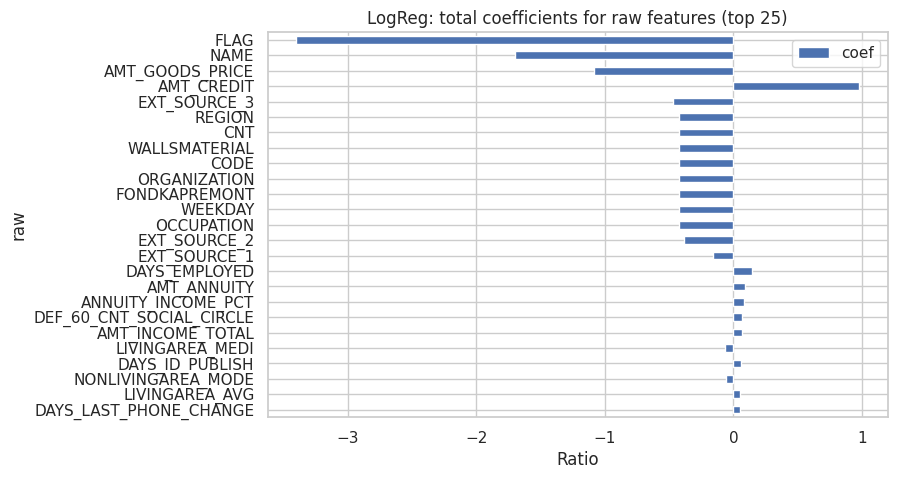

In [18]:

def aggregate_logreg_coeffs(pipe: Pipeline) -> pd.DataFrame:
    pre = pipe.named_steps['pre']
    model: LogisticRegression = pipe.named_steps['model']

    # names after preprocessing
    feat_names = get_feature_names_after_preprocess(pre)
    coefs = model.coef_.ravel()

    # mapping to "raw" features
    to_raw = map_transformed_to_raw(pre)
    df_coef = pd.DataFrame({'transformed': feat_names, 'coef': coefs})
    df_coef['raw'] = df_coef['transformed'].map(lambda x: to_raw.get(x, x))
    agg = df_coef.groupby('raw', as_index=False)['coef'].sum()
    agg['abs_coef'] = agg['coef'].abs()
    return agg.sort_values('abs_coef', ascending=False)

# Let's train on the whole train to get the final coefficients
pipe_lr.fit(X_train, y_train)
agg_lr = aggregate_logreg_coeffs(pipe_lr)
display(agg_lr.head(20))

ax = agg_lr.head(25).iloc[::-1].plot(kind='barh', x='raw', y='coef')
ax.set_title('LogReg: total coefficients for raw features (top 25)')
ax.set_xlabel('Ratio')
plt.show()


**Comment (Fig. 14. LR coefficients aggregated by "raw" features).**  
The signs of the coefficients are consistent with the economic meaning: an increase in external scores and age reduces risk (negative coefficients), an increase in debt burden increases (positive). Aggregation by "raw" features eliminates OHE artifacts.



###2) Decision Tree — rules


In [19]:

pipe_dt.fit(X_train, y_train)
dt: DecisionTreeClassifier = pipe_dt.named_steps['model']
rules = export_text(dt, feature_names=list(get_feature_names_after_preprocess(pipe_dt.named_steps['pre'])))
print(rules[:3000])


|--- EXT_SOURCE_3 <= 0.31
|   |--- EXT_SOURCE_2 <= 0.35
|   |   |--- EXT_SOURCE_3 <= 0.16
|   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.16
|   |   |   |--- EXT_SOURCE_2 <= 0.21
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.21
|   |   |   |   |--- class: 0
|   |--- EXT_SOURCE_2 >  0.35
|   |   |--- EXT_SOURCE_3 <= 0.13
|   |   |   |--- EXT_SOURCE_2 <= 0.59
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.59
|   |   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.13
|   |   |   |--- EXT_SOURCE_2 <= 0.62
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.62
|   |   |   |   |--- class: 0
|--- EXT_SOURCE_3 >  0.31
|   |--- EXT_SOURCE_2 <= 0.39
|   |   |--- EXT_SOURCE_3 <= 0.56
|   |   |   |--- EXT_SOURCE_2 <= 0.15
|   |   |   |   |--- class: 0
|   |   |   |--- EXT_SOURCE_2 >  0.15
|   |   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_3 >  0.56
|   |   |   |--- EXT_SOURCE_2 <= 0.14
|   |   |   |   |--- class: 0
|   |   |   |---

**Comment (Fig. 15. Rules of the decision tree).**  
The rules can easily be translated into business policy ("if `EXT_SOURCE_3` is below the threshold and the age is low, the risk is high"). For stability, we limit the depth and minimum size of the sheet; this prevents overfitting and facilitates verification.


###3) LightGBM — Importance and Partial Dependencies (PDP)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.095646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6222
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 165
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,raw,gain
20,EXT_SOURCE_3,60318.036897
19,EXT_SOURCE_2,53562.609874
12,CREDIT_ANNUITY_RATIO,24675.888439
18,EXT_SOURCE_1,19778.695347
28,NAME,10885.414503
14,DAYS_EMPLOYED,10358.282696
3,AMT_GOODS_PRICE,6789.479750
13,DAYS_BIRTH,6503.465788
1,AMT_ANNUITY,5876.483275
0,AGE_YEARS,5690.646841


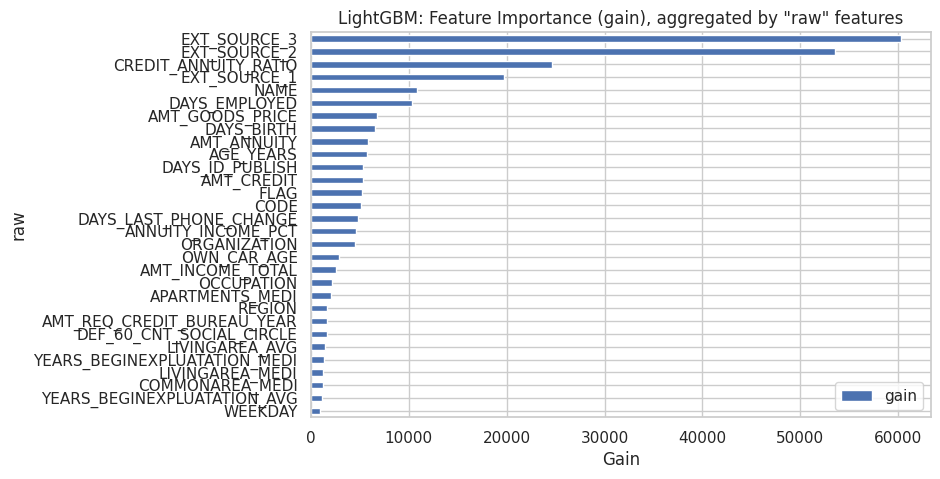

<Figure size 800x500 with 0 Axes>

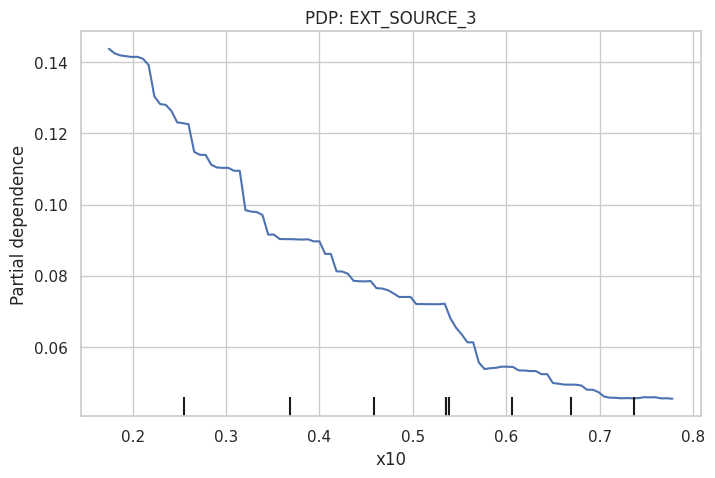

<Figure size 800x500 with 0 Axes>

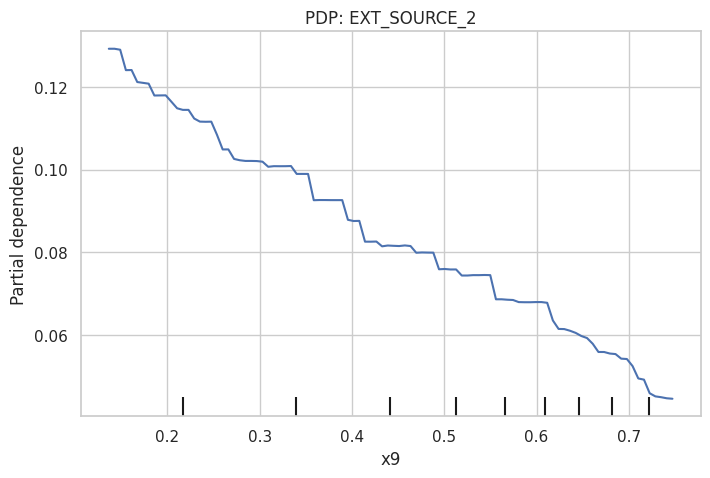

<Figure size 800x500 with 0 Axes>

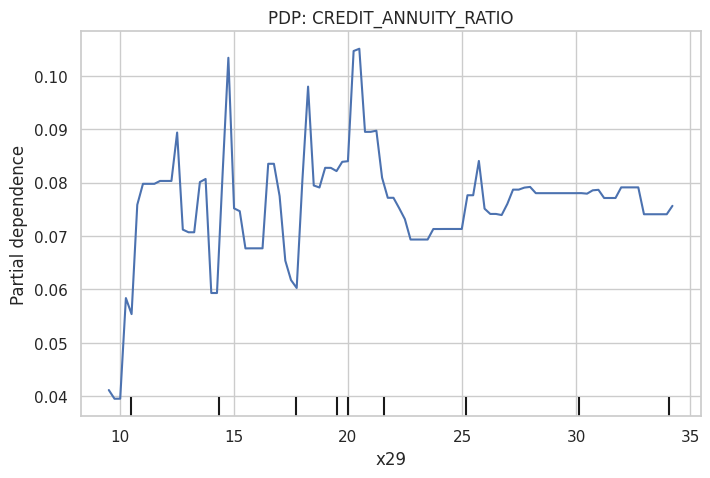

In [20]:

if pipe_lgbm is not None:
    pipe_lgbm.fit(X_train, y_train)
    pre = pipe_lgbm.named_steps['pre']
    model: LGBMClassifier = pipe_lgbm.named_steps['model']

    feat_names_trans = get_feature_names_after_preprocess(pre)
    to_raw = map_transformed_to_raw(pre)
    importances = model.booster_.feature_importance(importance_type='gain')
    df_imp = pd.DataFrame({'transformed': feat_names_trans, 'gain': importances})
    df_imp['raw'] = df_imp['transformed'].map(lambda x: to_raw.get(x, x))

    agg_imp = df_imp.groupby('raw', as_index=False)['gain'].sum().sort_values('gain', ascending=False)
    display(agg_imp.head(30))

    ax = agg_imp.head(30).iloc[::-1].plot(kind='barh', x='raw', y='gain')
    ax.set_title('LightGBM: Feature Importance (gain), aggregated by "raw" features')
    ax.set_xlabel('Gain')
    plt.show()

    top_pdp = agg_imp.head(3)['raw'].tolist()
    for raw_name in top_pdp:
        # find one transformed column corresponding to raw_name
        candidates = [t for t in feat_names_trans if to_raw.get(t, None) == raw_name]
        if not candidates:
            continue
        plt.figure()
        try:
            PartialDependenceDisplay.from_estimator(model, pre.transform(X_test), [list(feat_names_trans).index(candidates[0])])
            plt.title(f'PDP: {raw_name}')
            plt.show()
        except Exception as ex:
            print(f'Failed to build a PDP for {raw_name}:', ex)
else:
    print("LightGBM is unavailable.")


**Commentary (Fig. 16. The importance of LightGBM; Fig. 17-19. PDP).**  
The aggregated importance of the "raw" features confirms the results of permutations and SHAP. **PDPs** demonstrate the expected monotonies: risk decreases with increasing external scores and age, and increases with increasing credit/income ratio. These graphs are useful for checking **policy constraints** (e.g. monotony) before deployment.


## LLM-assisted explanation layer: textual explanation of the credit decision

In this section, the LLM is used as an interpretation layer on top of the already trained `LightGBM`/`LogisticRegression` model.

Block idea:

- the tabular model calculates the probability of default;
- SHAP or model coefficients identify the factors that increase/decrease the risk;
- the LLM converts these factors into a short business explanation in English.

This approach is useful for presenting the results: SHAP plots remain the basis for interpretation, while the LLM helps automatically generate a clear textual risk memo for an individual application.


In [21]:
%pip install -q transformers accelerate sentencepiece

In [22]:
from IPython.display import Markdown, display
import json
import textwrap


def _safe_scalar(value):
    """Short representation of a feature value for prompts and tables."""
    if pd.isna(value):
        return "missing"
    if isinstance(value, (float, np.floating)):
        return round(float(value), 4)
    if isinstance(value, (int, np.integer)):
        return int(value)
    text = str(value)
    return text[:80] + "..." if len(text) > 80 else text


def risk_bucket(probability: float) -> str:
    """Risk category for the text report."""
    if probability < 0.05:
        return "low"
    if probability < 0.12:
        return "moderate"
    if probability < 0.25:
        return "elevated"
    return "high"


def map_transformed_to_raw_robust(fitted_pre: ColumnTransformer) -> Dict[str, str]:
    """
    More robust mapping from transformed features to raw features.
    This is important for one-hot encoded features when original column names contain underscores.
    """
    mapping = {}
    for name, trans, cols in fitted_pre.transformers_:
        cols = list(cols)
        if name == "num":
            for col in cols:
                mapping[str(col)] = str(col)
        elif name == "cat":
            last_step_name, last_step = trans.steps[-1]
            if hasattr(last_step, "get_feature_names_out"):
                transformed_names = list(last_step.get_feature_names_out(cols))
                for tname in transformed_names:
                    tname = str(tname)
                    matched_raw = None
                    # OneHotEncoder usually creates names in the RAW_CATEGORY format.
                    for raw_col in sorted(cols, key=lambda x: len(str(x)), reverse=True):
                        raw_col = str(raw_col)
                        if tname == raw_col or tname.startswith(raw_col + "_"):
                            matched_raw = raw_col
                            break
                    mapping[tname] = matched_raw if matched_raw is not None else tname
            else:
                for col in cols:
                    suffix = "__ord" if last_step_name == "ord" else "__enc"
                    mapping[f"{col}{suffix}"] = str(col)
    return mapping


def get_base_scoring_pipeline():
    """Selects the main scoring model for the LLM explanation."""
    if globals().get("pipe_lgbm") is not None:
        return pipe_lgbm, "LightGBM"
    if globals().get("pipe_lr") is not None:
        return pipe_lr, "LogisticRegression"
    raise RuntimeError("Run the Holdout training block first so that pipe_lgbm or pipe_lr is available.")


def ensure_pipeline_is_fitted(pipe: Pipeline, sample_row: pd.DataFrame):
    """If the pipeline is not fitted in the current runtime, fit it on X_train/y_train."""
    try:
        _ = pipe.predict_proba(sample_row)
        return pipe
    except Exception:
        if "X_train" in globals() and "y_train" in globals():
            pipe.fit(X_train, y_train)
            return pipe
        raise RuntimeError("The pipeline is not fitted, and X_train/y_train are not available for fit().")


def local_explanation_table(pipe: Pipeline, x_row: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Returns local feature contributions for one application.
    SHAP is used for LightGBM; for LogisticRegression, an approximate x * coefficient contribution is used.
    """
    pre = pipe.named_steps["pre"]
    model = pipe.named_steps["model"]
    x_trans = pre.transform(x_row)
    if hasattr(x_trans, "toarray"):
        x_trans = x_trans.toarray()
    x_trans = np.asarray(x_trans)

    feat_names = get_feature_names_after_preprocess(pre)
    to_raw = map_transformed_to_raw_robust(pre)

    method = None
    contrib = None

    # Preferred option: SHAP for tree-based models / LightGBM.
    if HAS_SHAP and HAS_LGBM and isinstance(model, LGBMClassifier):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(x_trans)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = np.asarray(shap_values)
        if shap_values.ndim == 3:
            # Some SHAP versions return the shape: samples x features x classes.
            shap_values = shap_values[:, :, 1]
        contrib = shap_values[0]
        method = "SHAP value"

    # Fallback: linear approximation for Logistic Regression.
    elif hasattr(model, "coef_"):
        contrib = x_trans[0] * model.coef_.ravel()
        method = "x * coefficient"

    else:
        raise RuntimeError("No available local interpretation method for the selected model.")

    df_local = pd.DataFrame({
        "transformed_feature": feat_names,
        "raw_feature": [to_raw.get(str(f), str(f)) for f in feat_names],
        "contribution": contrib,
    })
    df_local = (
        df_local.groupby("raw_feature", as_index=False)["contribution"]
        .sum()
        .assign(abs_contribution=lambda d: d["contribution"].abs())
        .sort_values("abs_contribution", ascending=False)
        .head(top_n)
    )
    df_local["direction"] = np.where(
        df_local["contribution"] > 0,
        "increases risk",
        "decreases risk"
    )
    df_local["value"] = df_local["raw_feature"].map(
        lambda col: _safe_scalar(x_row.iloc[0][col]) if col in x_row.columns else "not available"
    )
    df_local["method"] = method
    return df_local[["raw_feature", "value", "contribution", "direction", "method"]]


# Demonstration application for explanation.
EXAMPLE_ROW_ID = 0
base_pipe, base_model_name = get_base_scoring_pipeline()
client_row = X_test.iloc[[EXAMPLE_ROW_ID]].copy()
base_pipe = ensure_pipeline_is_fitted(base_pipe, client_row)

predicted_default_probability = float(base_pipe.predict_proba(client_row)[:, 1][0])
client_explanation_df = local_explanation_table(base_pipe, client_row, top_n=10)

print(f"Base model: {base_model_name}")
print(f"Predicted probability of default: {predicted_default_probability:.4f}")
print(f"Risk bucket: {risk_bucket(predicted_default_probability)}")
display(client_explanation_df)

Base model: LightGBM
Predicted probability of default: 0.0538
Risk bucket: moderate


,raw_feature,value,contribution,direction,method
3,AMT_GOODS_PRICE,688500.0,-0.318992,decreases risk,SHAP value
14,DAYS_EMPLOYED,-105.0,0.270314,increases risk,SHAP value
36,NAME_EDUCATION_TYPE,Higher education,-0.216243,decreases risk,SHAP value
12,CREDIT_ANNUITY_RATIO,25.1102,-0.164116,decreases risk,SHAP value
20,EXT_SOURCE_3,0.4277,0.131888,increases risk,SHAP value
43,ORGANIZATION_TYPE,Transport: type 4,0.131718,increases risk,SHAP value
19,EXT_SOURCE_2,0.5943,-0.125736,decreases risk,SHAP value
10,CODE_GENDER,M,0.120590,increases risk,SHAP value
18,EXT_SOURCE_1,missing,0.111672,increases risk,SHAP value
26,FLAG_OWN_CAR,Y,-0.103071,decreases risk,SHAP value


In [23]:
# A small instruction-tuned LLM for generating explanations.
# The model can be replaced with a stronger one if a GPU is available, for example a larger Mistral/Qwen model.
LLM_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
USE_LOCAL_LLM = True

def load_local_llm(model_name: str = LLM_MODEL_NAME):
    """Loads a text-generation pipeline. If the LLM is unavailable, returns None."""
    if not USE_LOCAL_LLM:
        return None
    try:
        import torch
        from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype="auto",
            device_map="auto"
        )
        generator = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer
        )
        print(f"LLM loaded: {model_name}")
        return generator
    except Exception as ex:
        print("Failed to load the local LLM. A fallback without a generative model will be used.")
        print("Reason:", ex)
        return None


llm_generator = load_local_llm()

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded: Qwen/Qwen2.5-0.5B-Instruct


In [24]:
def build_llm_prompt(
    model_name: str,
    probability: float,
    explanation_df: pd.DataFrame,
    max_factors: int = 8
) -> str:
    """Builds a strict English prompt: the LLM can rely only on the provided facts."""
    evidence = explanation_df.head(max_factors).copy()
    evidence["contribution"] = evidence["contribution"].round(5)
    evidence_records = evidence.to_dict(orient="records")

    prompt = f"""
You are a credit risk analyst. Your task is to explain the prediction of a machine learning model in clear business English.

Context:
- Main model: {model_name}
- Predicted probability of default: {probability:.4f}
- Risk category: {risk_bucket(probability)}
- Local model factors are listed below. A positive contribution increases the predicted risk, while a negative contribution decreases it.

Evidence for the explanation. Use only these facts:
{json.dumps(evidence_records, ensure_ascii=False, indent=2)}

Response rules:
1. Do not invent features, reasons, or client characteristics that are not present in the evidence.
2. Do not claim causality. Use phrases such as “is associated with”, “is linked in the model”, or “has a model contribution”.
3. Do not make the final credit approval or rejection decision.
4. State that the text is a model explanation, not a legal or final credit decision.
5. Answer in English only. Do not use Russian.

Response structure:
- Brief risk summary.
- Factors increasing the risk.
- Factors decreasing the risk.
- Interpretation limitations.
- Practical recommendation for the analyst.
""".strip()
    return prompt


def rule_based_explanation(model_name: str, probability: float, explanation_df: pd.DataFrame) -> str:
    """Fallback text if the LLM fails to load."""
    risk_up = explanation_df[explanation_df["contribution"] > 0].head(4)
    risk_down = explanation_df[explanation_df["contribution"] < 0].head(4)

    def _format_rows(rows):
        if rows.empty:
            return "- No strong factors in this group."
        return "\n".join(
            f"- `{r.raw_feature}` = {r.value}: contribution {r.contribution:.4f}, {r.direction}."
            for r in rows.itertuples(index=False)
        )

    return f"""
### LLM-style explanation fallback

**Brief risk summary.** The `{model_name}` model estimated the probability of default as **{probability:.2%}**, which corresponds to a **{risk_bucket(probability)}** risk category.

**Factors increasing the risk:**
{_format_rows(risk_up)}

**Factors decreasing the risk:**
{_format_rows(risk_down)}

**Interpretation limitations.** This explanation is based on local model contributions. It does not prove causality and should not be treated as a final credit decision.

**Practical recommendation.** The analyst should review the strongest contributing features and compare them with internal credit policy, data quality checks, and compliance requirements.
""".strip()


def generate_llm_explanation(prompt: str, generator, max_new_tokens: int = 450) -> str:
    """Generates LLM text with chat template support and fallback."""
    if generator is None:
        return rule_based_explanation(base_model_name, predicted_default_probability, client_explanation_df)

    system_message = (
        "You write careful and verifiable explanations of machine learning models. "
        "Use only the facts provided in the user prompt. "
        "Always answer in English."
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": prompt},
    ]

    tokenizer = generator.tokenizer
    try:
        model_input = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except Exception:
        model_input = system_message + "\n\n" + prompt

    output = generator(
        model_input,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False
    )[0]["generated_text"]
    return output.strip()


llm_prompt = build_llm_prompt(
    model_name=base_model_name,
    probability=predicted_default_probability,
    explanation_df=client_explanation_df,
)

llm_explanation = generate_llm_explanation(llm_prompt, llm_generator)
display(Markdown(llm_explanation))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=450) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The machine learning model predicts a moderate risk level of default (probability of 0.0538). The main contributing factors include:

- **AMT_GOODS_PRICE**: A positive contribution increases the predicted risk.
- **DAYS_EMPLOYED**: A negative contribution decreases the predicted risk.
- **NAME_EDUCATION_TYPE**: A positive contribution increases the predicted risk.
- **CREDIT_ANNUITY_RATIO**: A negative contribution decreases the predicted risk.
- **EXT_SOURCE_3**: A positive contribution increases the predicted risk.
- **ORGANIZATION_TYPE**: A positive contribution increases the predicted risk.
- **EXT_SOURCE_2**: A negative contribution decreases the predicted risk.
- **CODE_GENDER**: A positive contribution increases the predicted risk.

### Explanation

The model's predictions suggest a moderate risk level of default. This can be attributed to several factors:

1. **High AMT_GOODS_PRICE**: Higher prices may indicate higher financial strain on the borrower, which could lead to increased costs and reduced income, thus raising the likelihood of default.
   
2. **Negative Days Employed**: Employing less than average can increase the risk of default due to potential economic downturns or job loss, making the borrower more vulnerable financially.

3. **Positive NAME_EDUCATION_TYPE**: People with higher education levels tend to have better financial stability and fewer risks associated with default, indicating they are less likely to default.

4. **Positive CREDIT_ANNUITY_RATIO**: Lower credit annuity ratios generally mean lower monthly payments, reducing the overall financial burden on the borrower and potentially lowering the risk of default.

5. **Negative EXT_SOURCE_3**: Sources like transportation services often come with high fees, which can significantly impact the borrower’s finances, thereby increasing their risk of default.

6. **Positive ORGANIZATION_TYPE**: Organizations involved in transport activities typically require more frequent and detailed documentation, which can add complexity and cost to the loan process, further increasing the risk of default.

7. **Positive CODE_GENDER**: Women are more likely to default compared to men, suggesting gender-specific risk profiles.

These factors collectively contribute to a moderate risk level of default, necessitating prudent lending practices and additional monitoring to mitigate potential risks.

**Interpretation of the LLM block.**

The LLM does not replace the scoring model and is not trained on tabular data. Its role is to generate a clear textual explanation based on already calculated values: the probability of default and the local feature contributions. This reduces the gap between the technical interpretation of SHAP values/model coefficients and business communication with a risk manager.

To reduce the risk of hallucinations, the prompt restricts the LLM to the provided factors only and explicitly forbids making the final credit decision. In a production scenario, this text should be logged together with the model version, prompt version, and the original SHAP values.

## Conclusions and recommendations

- **Encoding strategy.**
  - `OneHot` is usually best for linear models (transparent and stable).
  - For trees/boosting, `Ordinal` is often enough; for high-cardinality features, use `Target/CatBoostEncoder` inside a leakage-safe `Pipeline`.
- **Feature selection.**
  - `Permutation Importance` gives raw-feature-level importance and is easy to communicate.
  - `SHAP` provides global and local explanations.
  - `SelectKBest` (mutual information) is a fast screening method.
- **Models and neural additions.**
  - `LogisticRegression` provides maximal interpretability.
  - `DecisionTree` provides explicit rules.
  - `MLP small` and `MLP deep` act as lightweight nonlinear benchmarks.
  - `LightGBM` in a shallow setup gives strong quality with explainability support.
- **LLM explanation layer.**
  - A small instruction-tuned LLM can convert probability + SHAP/coefficients into a readable risk memo.
  - The LLM is not used for the final score; it only explains the validated tabular model.

Optional next upgrades: probability calibration, monotonic constraints, and extended benchmark with CatBoost/XGBoost.


## Final summary

**Methodology.** Stratified cross-validation, leakage-safe sklearn pipelines, and probabilistic metrics (ROC-AUC, AP, LogLoss) were used for all comparisons.

**Main results.**
1) EDA confirms expected risk patterns (`EXT_SOURCE_*`, age, debt load).
2) Encoding choice depends on model family (OneHot for linear/MLP, Ordinal or target-style encoders for boosting).
3) Feature-selection methods show consistent core predictors.
4) Added neural baselines (`MLP small`, `MLP deep`) help test nonlinear signal beyond classical methods.
5) Interpretable LightGBM remains a strong quality/explainability compromise.
6) An LLM-assisted explanation layer can turn local model evidence into a concise Russian-language risk memo.

**Limitations.** This study is based on a tabular snapshot without all external tables and without production-time drift effects.

**Reproducibility.** Random seeds and preprocessing configuration are fixed; library versions should be pinned in the final environment.

**Practical recommendation.**
- keep leakage-safe preprocessing;
- use LightGBM for primary scoring;
- keep Logistic Regression and Decision Tree for explainability;
- keep MLP as an additional quality benchmark;
- use the LLM-assisted explanation layer only as a reporting aid, not as the scoring model;
- monitor drift and recalibrate probabilities when needed.


### Detailed interpretation and comments

In this section, we summarize the main findings and interpretations based on the results of EDA, feature selection, and model analysis.

**Class imbalance.** The target variable `TARGET` is highly imbalanced: approximately 8–9% of applications correspond to defaults, while the remaining 91–92% correspond to successful repayment. Therefore, model evaluation should focus on ROC-AUC, PR-AUC, and F1-score, use stratified splitting, and take into account the effect of class imbalance on decision thresholds.

**Missing values.** Many features contain missing values: `EXT_SOURCE_1/2/3` have around 20–30% missing values, car age (`OWN_CAR_AGE`) is available only for car owners, and some social characteristics are only partially filled. Missingness is often related to client characteristics, such as the absence of credit history, so separate `missing` categories or missing-value indicators are important. Features with 100% missing values can be removed.

**Relationship between features and risk.** Correlation analysis shows that the strongest negative correlates with `TARGET` are the external scoring variables `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`: the higher these scores are, the lower the default risk. The relationship with age (`DAYS_BIRTH`) is also confirmed: younger borrowers are more likely to become overdue. Positive correlates include the credit amount and annuity (`AMT_CREDIT`, `AMT_ANNUITY`), the credit-to-income ratio, and the abnormally large employment value (`DAYS_EMPLOYED = 365243`), which indicates the absence of official employment history.

**Categorical features.** Analysis of the target distribution across categories shows that clients without their own housing or car, those working in temporary/seasonal positions, or single clients tend to have a higher default risk. In contrast, higher education, owning an apartment, owning a car, and stable employment are associated with lower risk.

**Encoding methods.** There is no universal encoder. For linear models such as Logistic Regression, One-Hot Encoding is optimal because the model can interpret each category separately. For tree-based models such as Decision Tree and LightGBM, simple Ordinal Encoding is sufficient because the model can find thresholds itself. For high-cardinality features such as `ORGANIZATION_TYPE` or `OCCUPATION_TYPE`, target encoding, such as Target Encoder or CatBoost Encoder, can be useful because it reduces dimensionality and improves stability. However, it must be applied only inside cross-validation to avoid target leakage.

**Feature selection.** Permutation Importance identifies the same key features as the correlation analysis: `EXT_SOURCE_*`, age, employment length, and credit-to-income ratios. SelectKBest based on mutual information confirms their importance but may miss feature interactions. SHAP values for the LightGBM model provide a detailed view of each feature’s contribution to the prediction, which is convenient for explaining individual credit decisions.

**Model interpretation.** In Logistic Regression, negative coefficients for `EXT_SOURCE_*` and age mean that risk decreases as these feature values increase, while positive coefficients for the credit amount and debt burden indicate increased risk. The Decision Tree most often splits the data by `EXT_SOURCE_3` or `DAYS_BIRTH`: high values lead to a “safe” branch, while low values lead to a “risky” branch. LightGBM shows the largest improvement in quality and confirms the same patterns. Partial dependence plots (PDP) demonstrate, for example, a monotonic decrease in the probability of default as external scores and age increase.

**Recommendations.** For building a credit scoring system, it is reasonable to combine several levels of models: use boosting models such as LightGBM or CatBoost for accurate prediction and explain them with SHAP plots; at the same time, train simpler interpretable models such as Logistic Regression and Decision Tree on selected features for transparency and business communication. It is important to monitor data drift over time and retrain models regularly, as well as carefully analyze features to avoid discrimination and the use of sensitive information.